# Benchmark Evaluation Notebook - Single SBML

_Adapted from Jonah R. Huggins_

Execute the first cell below, others can be executed in any order after.

In [2]:
# Packages import
import os
import sys
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings; warnings.simplefilter('ignore')
from scipy.optimize import curve_fit

plt.rcParams["font.family"] = "DejaVu Sans"

# Get the directory path
wd = os.path.dirname(os.getcwd())

# Create the formatted path to the SPARCED input files
project_root = ('..')

sys.path.append(os.path.join(project_root))

from viz_helpers import *


# Set global font to DejaVu Sans
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 14,            # default size for all text
    'axes.titlesize': 16,       # axes title size
    'axes.labelsize': 14,       # x/y label size
    'xtick.labelsize': 12,      # x tick label size
    'ytick.labelsize': 12,      # y tick label size
    'legend.fontsize': 12       # legend font size
})

#prompt user for the date of simulation
def get_data_title():
    """Basic function for prompting the user for the benchmark's name. Applied 
    In Every Benchmark Cell."""
    return input('Enter the name of the simulation, default is date of (YYYY-MM-DD): ')

### TRAIL Time To Death Benchmark
[Compare to Erdem et al. Supp. Fig. 7ab](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Increasing simulated TRAIL dose decreases the time it takes to die for an average cell.

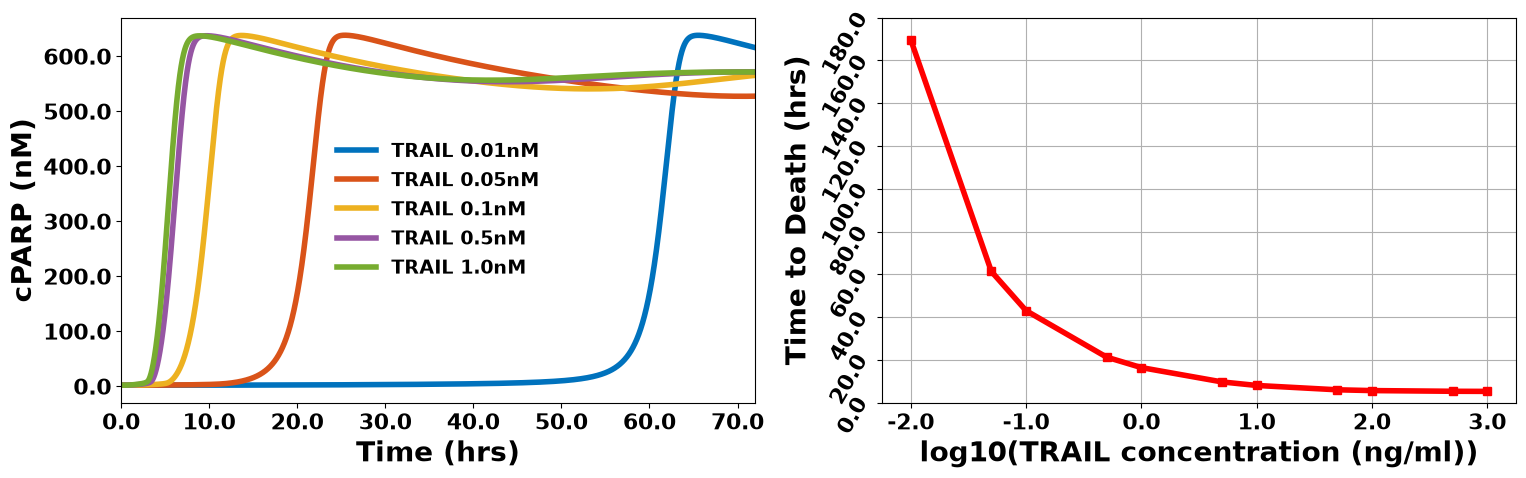

In [7]:
with open(f'../TRAIL-time-to-death/TRAIL-time-to-death.pkl', 'rb') as f:
    data = pickle.load(f)

traildoses = np.array([0.000385, 0.001925, 0.00385, 0.01925, 0.0385, 0.1925, 0.385, 1.9250, 3.85, 19.25, 38.5])
dosesngperml = np.round((traildoses*2.597402597402597e+01), decimals=2)

sims = []
for sim in data['TRAIL-ttd'].keys():
    sims.append(sim)

colors = ["", "#0072bd", "", "#d95319", "", "#edb120", "",  "#9656a3", "", "#77ac30"]

legend = []
for dose in dosesngperml:
    legend.append('TRAIL ' + str(dose) + 'nM')
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
for i in range(1,11,2):

    axs[0].plot(data['TRAIL-ttd'][sims[i]]['cPARP_total']['time']/3600, 
                data['TRAIL-ttd'][sims[i]]['cPARP_total']['simulation'], linewidth=4, color=colors[i])
    axs[0].set_xlim([0, 72])
    axs[0].set_xticklabels(axs[0].get_xticks(), fontsize=16, weight='bold')
    axs[0].set_yticklabels(axs[0].get_yticks(), fontsize=16, weight='bold')
    legend_properties = {'weight':'bold', 'size':14}
    axs[0].legend(labels=legend, loc='best', fontsize=14, frameon=False, prop=legend_properties)

conditions = ["TRAIL_3p85eNeg4", "TRAIL_1p925eNeg3", "TRAIL_3p85eNeg3", "TRAIL_1p925eNeg2", "TRAIL_3p85eNeg2",
              "TRAIL_1p925eNeg1", "TRAIL_3p85eNeg1", "TRAIL_1p925", "TRAIL_3p85", "TRAIL_19p25", "TRAIL_38p5"]

ttd = {cond: 0 for cond in conditions} # time to death

for sim in data['TRAIL-ttd'].keys():

    condition_id = data['TRAIL-ttd'][sim]['conditionId']
    cell = data['TRAIL-ttd'][sim]['cell']

    cparp = data['TRAIL-ttd'][sim]["cPARP_total"]["simulation"].tolist()
    parp = data['TRAIL-ttd'][sim]["PARP_total"]["simulation"].tolist()
    time = data['TRAIL-ttd'][sim]["cPARP_total"]["time"].tolist()

    for idx, (c, p, t) in enumerate(zip(cparp, parp, time)):
        
        if c > p:
            ttd[condition_id] = time[idx]
            break

axs[1].plot(np.log10(dosesngperml),[tod/3600 for tod in ttd.values()],marker='s',linewidth=4, color='red')
axs[1].set_xticklabels(axs[1].get_xticks(), fontsize=16, weight='bold')
axs[1].set_ylim(ymin=0.0, ymax=180.0)
axs[1].set_yticklabels(axs[1].get_yticks(), fontsize=16, weight='bold', rotation=60)
axs[1].grid(True)

# Set the x-axis label
axs[1].set_xlabel('log10(TRAIL concentration (ng/ml))', weight='bold', fontsize=20)
axs[1].set_ylabel( 'Time to Death (hrs)', va='center', rotation='vertical',
                    weight='bold', fontsize=20, labelpad=15)
axs[0].set_xlabel('Time (hrs)', weight='bold', fontsize=20)
axs[0].set_ylabel('cPARP (nM)', weight='bold', fontsize=20)


fig.savefig(f'./TRAIL-time-to-death.png', dpi=300, bbox_inches='tight')

### Survival Signaling Benchmark
[Compare to Erdem et al. Supp. Fig. 7d](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Increasing ERK and AKT activity levels prolongs TRAIL induced time to death, whereas increasing PUMA and NOXA expression levels decreases the time it takes for cells to die.

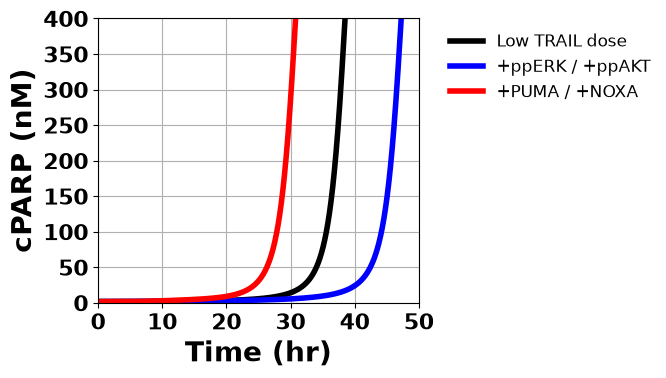

In [8]:
with open(f'../survival-signaling/survival-signaling.pkl', 'rb') as f:
    data = pickle.load(f)

conditions = []
for condition in data['survival-signaling']:
    conditions.append(condition)

plt.figure(figsize=(7, 4))
plt.plot(data['survival-signaling'][conditions[0]]['cPARP_total']['time']/3600, 
         data['survival-signaling'][conditions[0]]['cPARP_total']['simulation'], label='TRAIL only', linewidth=4, color='black')
plt.plot(data['survival-signaling'][conditions[1]]['cPARP_total']['time']/3600, 
         data['survival-signaling'][conditions[1]]['cPARP_total']['simulation'], label='+ppERK/+ppAKT', linewidth=4, color='blue')
plt.plot(data['survival-signaling'][conditions[2]]['cPARP_total']['time']/3600, 
         data['survival-signaling'][conditions[2]]['cPARP_total']['simulation'], label='+PUMA/+NOXA', linewidth=4, color='red')
plt.xlabel('Time (hr)', fontsize=20, weight='bold')
plt.ylabel('cPARP (nM)', fontsize=20, weight='bold')
plt.grid(True)
plt.xlim(0, 50)
plt.ylim(0, 400)
plt.xticks(fontsize=16, weight='bold')
plt.yticks(fontsize=16, weight='bold')
plt.legend(['Low TRAIL dose','+ppERK / +ppAKT','+PUMA / +NOXA'], bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(f'./survival-signaling.png'), dpi=300)

### Cell Cycle Benchmark
[Compare to Erdem et al. Supp Fig. 8a](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
Increasing Cyclin D mRNA levels induces proper cyclin-CDK complex progression and oscillations for cell cycle entry and progression.

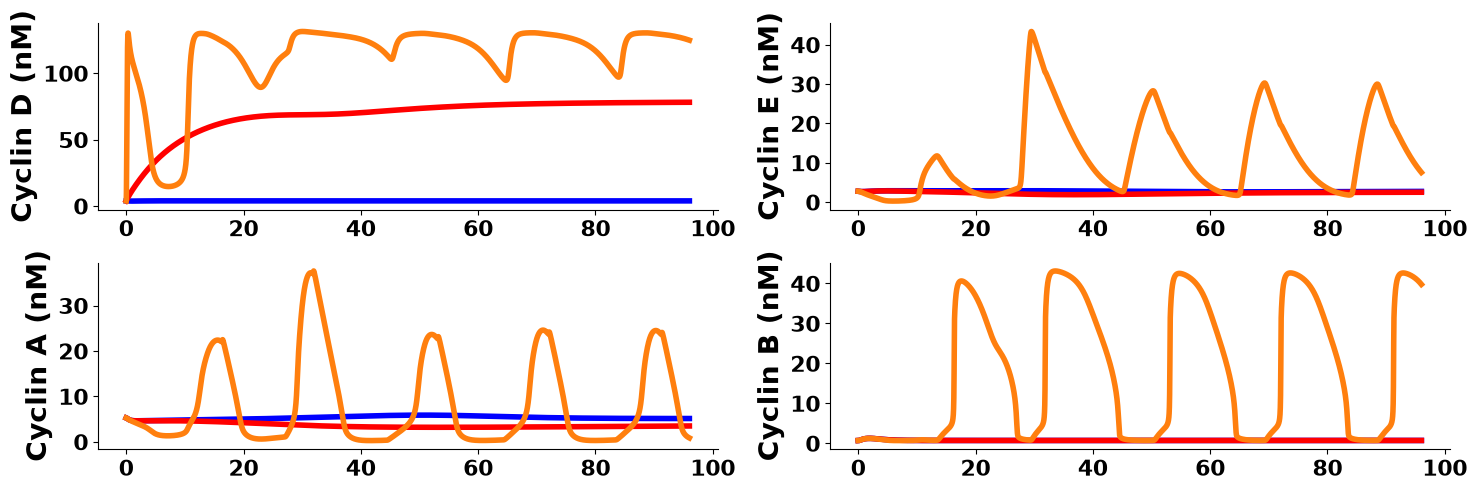

In [9]:
with open(f'../cell_cycle/cell_cycle.pkl', 'rb') as f:
    data = pickle.load(f)

conditions = []
for key in data['cell-cycle']:
    conditions.append(key)

fig, ax = plt.subplots(2,2, figsize=(15,5))
#Cyclin D plot
ax[0,0].plot(data['cell-cycle'][conditions[0]]['Cd_total']['time']/3600, data['cell-cycle'][conditions[0]]['Cd_total']['simulation'], linewidth=4, color='b')
ax[0,0].plot(data['cell-cycle'][conditions[1]]['Cd_total']['time']/3600, data['cell-cycle'][conditions[1]]['Cd_total']['simulation'], linewidth=4, color='r')
ax[0,0].plot(data['cell-cycle'][conditions[2]]['Cd_total']['time']/3600, data['cell-cycle'][conditions[2]]['Cd_total']['simulation'], linewidth=4, color='tab:orange')
ax[0,0].set_yticklabels(ax[0,0].get_yticks().astype(int), weight='bold', fontsize=16)
ax[0,0].spines[['right', 'top']].set_visible(False)
ax[0,0].set_xticklabels(ax[0,0].get_xticks().astype(int), weight='bold', fontsize=16)
ax[0,0].set_ylabel('Cyclin D (nM)', weight='bold', fontsize=20)

#Cyclin E plot
ax[0,1].plot(data['cell-cycle'][conditions[0]]['Ce_total']['time']/3600, data['cell-cycle'][conditions[0]]['Ce_total']['simulation'], linewidth=4, color='b')
ax[0,1].plot(data['cell-cycle'][conditions[1]]['Ce_total']['time']/3600, data['cell-cycle'][conditions[1]]['Ce_total']['simulation'], linewidth=4, color='r')
ax[0,1].plot(data['cell-cycle'][conditions[2]]['Ce_total']['time']/3600, data['cell-cycle'][conditions[2]]['Ce_total']['simulation'], linewidth=4, color='tab:orange')
ax[0,1].set_yticklabels(ax[0,1].get_yticks().astype(int), weight='bold', fontsize=16)
ax[0,1].set_xticklabels(ax[0,1].get_xticks().astype(int), weight='bold', fontsize=16)
ax[0,1].spines[['right', 'top']].set_visible(False)
ax[0,1].set_ylabel('Cyclin E (nM)', weight='bold', fontsize=20)
# ax[0,1].legend(['x1', 'x10', 'x60'], title = 'Basal Cyclin D mRNA', 
#                bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=16)

#Cyclin A plot
ax[1,0].plot(data['cell-cycle'][conditions[0]]['Ca_total']['time']/3600, data['cell-cycle'][conditions[0]]['Ca_total']['simulation'], linewidth=4, color='b')
ax[1,0].plot(data['cell-cycle'][conditions[1]]['Ca_total']['time']/3600, data['cell-cycle'][conditions[1]]['Ca_total']['simulation'], linewidth=4, color='r')
ax[1,0].plot(data['cell-cycle'][conditions[2]]['Ca_total']['time']/3600, data['cell-cycle'][conditions[2]]['Ca_total']['simulation'], linewidth=4, color='tab:orange')
ax[1,0].set_yticklabels(ax[1,0].get_yticks().astype(int), weight='bold', fontsize=16)
ax[1,0].set_xticklabels(ax[1,0].get_xticks().astype(int), weight='bold', fontsize=16)
ax[1,0].spines[['right', 'top']].set_visible(False)
ax[1,0].set_ylabel('Cyclin A (nM)', weight='bold', fontsize=20)

#Cyclin B plot
ax[1,1].plot(data['cell-cycle'][conditions[0]]['Cb_total']['time']/3600, data['cell-cycle'][conditions[0]]['Cb_total']['simulation'], linewidth=4, color='b')
ax[1,1].plot(data['cell-cycle'][conditions[1]]['Cb_total']['time']/3600, data['cell-cycle'][conditions[1]]['Cb_total']['simulation'], linewidth=4, color='r')
ax[1,1].plot(data['cell-cycle'][conditions[2]]['Cb_total']['time']/3600, data['cell-cycle'][conditions[2]]['Cb_total']['simulation'], linewidth=4, color='tab:orange')
ax[1,1].set_yticklabels(ax[1,1].get_yticks().astype(int), weight='bold', fontsize=16)
ax[1,1].set_xticklabels(ax[1,1].get_xticks().astype(int), weight='bold', fontsize=16)
ax[1,1].set_ylabel('Cyclin B (nM)', weight='bold', fontsize=20)
ax[1,1].spines[['right', 'top']].set_visible(False)

fig.tight_layout()
fig.savefig(f'./cell_cycle.png', dpi=300)

### Ribosome Doubling Rate Benchmark  
[Compare to Erdem et al. Supp. Fig. 8b](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
The number of ribosomes within the cell doubles within 24 h.

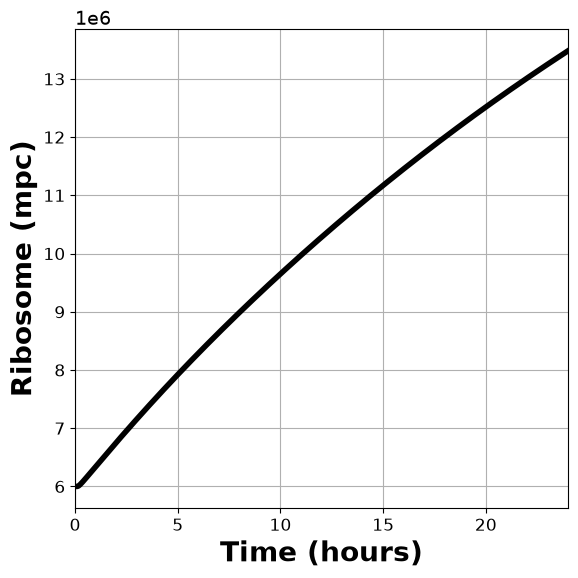

In [10]:
with open(f'../ribosome-doubling-rate/ribosome-doubling-rate.pkl', 'rb') as f:
    data = pickle.load(f)
Vc = 5.25E-12
import matplotlib.ticker as ticker
conditions = []
for condition in data['ribosome-doubling-rate']:
    conditions.append(condition)

import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(6, 6))
yy = np.array([value for value in data['ribosome-doubling-rate'][conditions[0]]['Ribosome_total']['simulation']])
tt = (data['ribosome-doubling-rate'][conditions[0]]['Ribosome_total']['time']/3600)

ax.plot(tt, yy, linewidth=4, color='black')
ax.set_xlim([0, 24])
ax.grid()
ax.set_ylabel('Ribosome (mpc)', fontsize=20, weight='bold')
ax.set_xlabel('Time (hours)', fontsize=20, weight='bold')

# Force scientific notation with desired exponent
ax.ticklabel_format(axis='y', style='sci', scilimits=(6,6))  # enforces 1E6
ax.yaxis.get_offset_text().set_fontsize(14)

plt.tight_layout()
plt.savefig(f'ribosome-doubling-rate.png')

### ERK and AKT Dose Dependent Responses Benchmark
[Compare to Erdem et al. Supp. fig 5](https://www.nature.com/articles/s41467-022-31138-1#MOESM1)\
EGF and insulin stimulation activates both ERK and AKT pathways. Dual stimulation with the two ligands induces prolonged AKT activation.

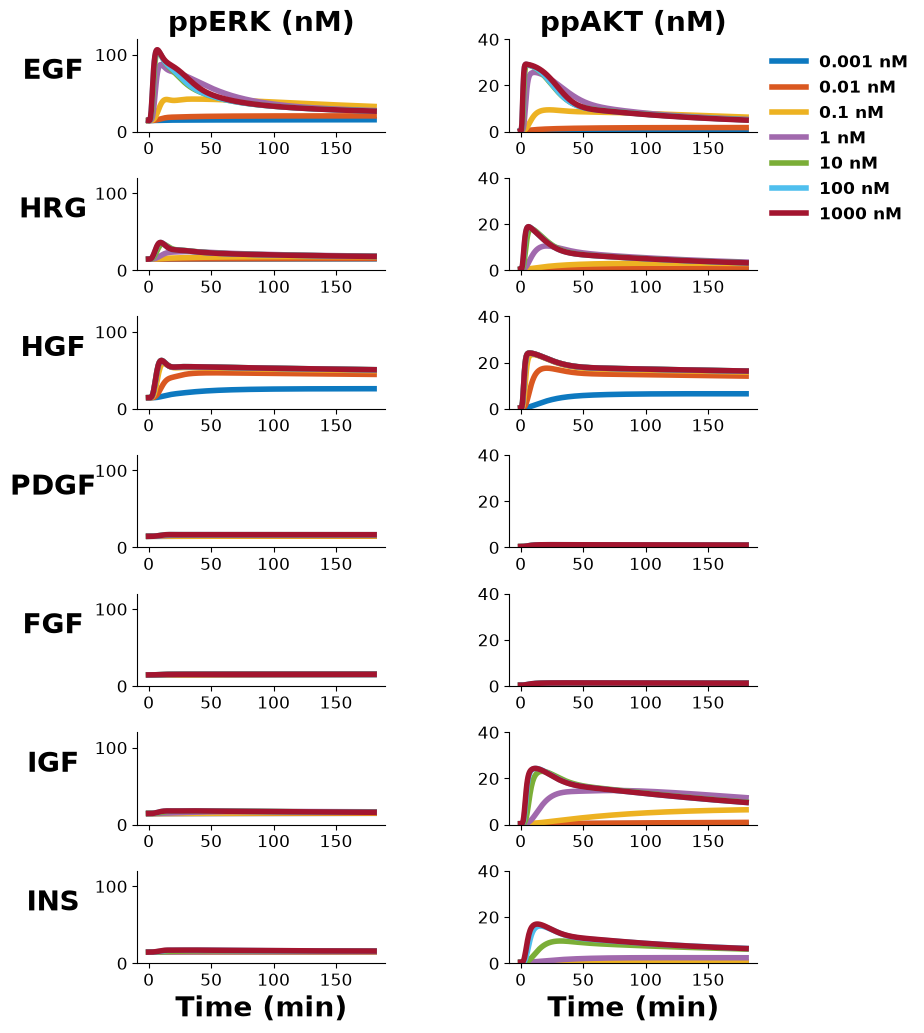

In [11]:
with open(f'../ERK-AKT-dose-response/ERK-AKT-dose-response.pkl', 'rb') as f:
    data = pickle.load(f)

conditional_strings = ['EGF', 'HRG', 'HGF', 'PDGF', 'FGF', 'IGF', 'INS']
colors = ["#0d79c0", "#da5820",  "#edb222",  "#a169ad","#7bae37","#4fbfee", "#a3152f"]
fig, axes = plt.subplots(7, 2, figsize=(8, 12))
conditions = []
for condition in data['ERK-AKT-dose-response']:
    conditions.append(condition)

for i in range(7):
    upper = (i+1)*7
    lower = upper - 7
    for j in range(lower, upper):
        axes[i, 0].plot(data['ERK-AKT-dose-response'][conditions[j]]['ppERK_total']['time'] / 60, 
                        data['ERK-AKT-dose-response'][conditions[j]]['ppERK_total']['simulation'], linewidth=4, color=colors[j-lower])
        axes[i, 1].plot(data['ERK-AKT-dose-response'][conditions[j]]['ppAKT_total']['time'] / 60, 
                        data['ERK-AKT-dose-response'][conditions[j]]['ppAKT_total']['simulation'], linewidth=4, color=colors[j-lower])

    axes[i, 0].set_ylim(0, 120)
    axes[i, 1].set_ylim(0, 40)
    axes[i, 0].set_ylabel(conditional_strings[i], fontsize=20, weight='bold', labelpad=30, rotation=0)
    axes[i,0].spines[['right', 'top']].set_visible(False)
    axes[i,1].spines[['right', 'top']].set_visible(False)
axes[6, 0].set_xlabel('Time (min)', fontsize = 20, weight='bold')
axes[6, 1].set_xlabel('Time (min)', fontsize = 20, weight='bold')

axes[0,0].set_title('ppERK (nM)', fontsize = 20, weight='bold')

axes[0,1].set_title('ppAKT (nM)', fontsize = 20, weight='bold')

legend_values = ['0.001 nM', '0.01 nM', '0.1 nM', '1 nM', '10 nM', '100 nM', '1000 nM']
legend_properties = {'weight':'bold'}
axes[0, 1].legend(labels = legend_values, loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=20, prop=legend_properties)


# plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.5)

fig.savefig(f'./ERK-AKT-dose-response.png', dpi=300, bbox_inches='tight')

## Validations Complete

## References:
* Erdem, C., Mutsuddy, A., Bensman, E.M. et al. A scalable, open-source implementation of a large-scale mechanistic model for single cell proliferation and death signaling. Nat Commun 13, 3555 (2022). [https://doi.org/10.1038/s41467-022-31138-1](https://doi.org/10.1038/s41467-022-31138-1)